In [9]:
from util.DataGen import *
from util.Processing import *
from util.Plotting import *

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm, Normalize
# import pymc as pm
# import arviz as az
import matplotlib
import time as time


(129, 129) (129,) (129,) (129,) (129,)
True Photons Response Integral: 0.36, Sum (both axes): 1.0
Dwyer Spectrum Integral: 3778479.00, Sum: 257862857.0
Dwyer Spectrum Integral 2: 0.12, Sum: 257862857.0
NaI - Dwyer Combined Response: 20969.45, Sum: 1568360.5850936007


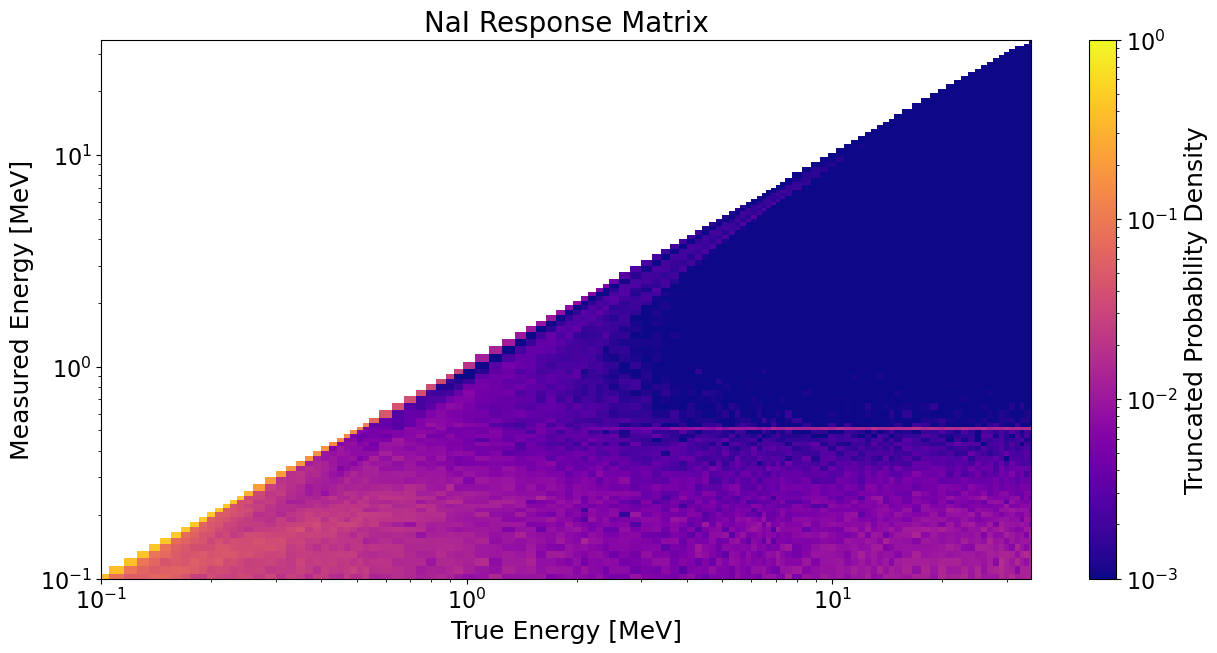

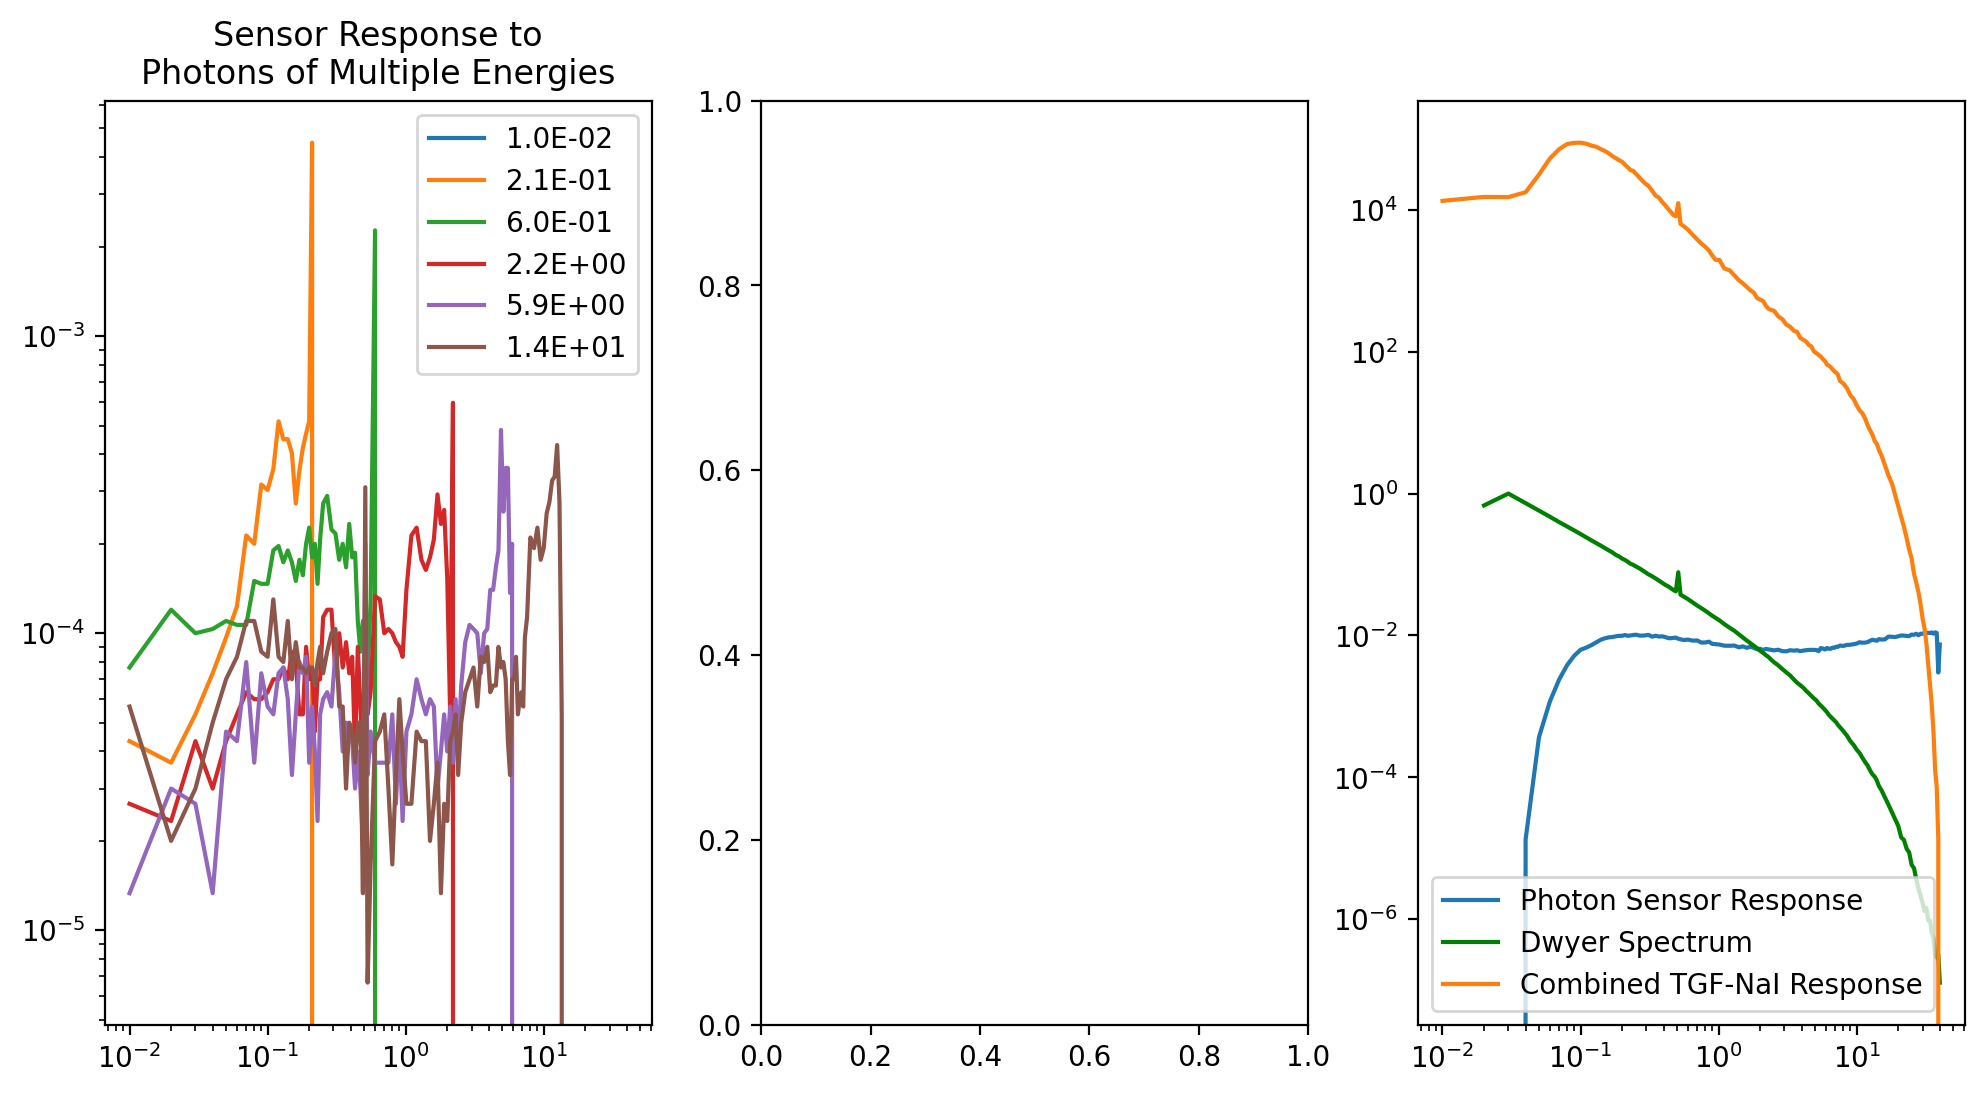

In [19]:
nai_distribution = np.load('Spectra/NaI_Distribution.npy')
nai_distribution = nai_distribution / np.sum(nai_distribution) # Normalize matrix into distribution
# print(nai_distribution.shape)

nai_spectrum_data = np.load('Spectra/NaI_Response.npy')
# print(nai_spectrum_data.shape)
bins = np.concatenate((nai_spectrum_data[:,0].ravel(), np.array([40.5]))) # Hacky
nai_spectrum_response = nai_spectrum_data[:,1]

cmap_color = 'plasma'
shading = 'auto'
binWidths = (bins - np.roll(bins, 1))[1:]
binCenters = (bins + np.roll(bins, 1))[1:]/2

def plot_distribution(data_, bins_, binWidths_):
    plt.figure()
    # print(bins_.shape, binWidths_.shape, data_.shape)
    plt.pcolormesh(bins_, bins_, (data_/binWidths_).T,
                   shading=shading,cmap=cmap_color, norm=LogNorm(vmin=1E-3, vmax=1E0))
    cb = plt.colorbar()
    cb.ax.tick_params(labelsize=16)
    cb.set_label(label='Truncated Probability Density',size=18)
    plt.xlim(.1,35)
    plt.ylim(.1,35)
    plt.xscale('log')
    plt.yscale('log')
    plt.title('NaI Response Matrix',fontsize=20)
    plt.xlabel('True Energy [MeV]',fontsize=18)
    plt.ylabel('Measured Energy [MeV]',fontsize=18)
    plt.tick_params(labelsize=16)
    plt.savefig('figures/nai_response_matrix.png')
    
plot_distribution(nai_distribution, bins, binWidths)

# print(np.sum(nai_distribution[:,0]), np.sum(nai_distribution[0, :])) # [True, Measured]


fig, axes = plt.subplots(1, 3, figsize=(12,6), dpi=200)
n = 20
for i in range(nai_distribution.shape[0]//n):
    index = i * n
    label = "{:.1E}".format(binCenters[index])
    axes[0].plot(binCenters, nai_distribution[index, :], label=label)
    
axes[0].set_title('Sensor Response to\nPhotons of Multiple Energies')
axes[0].legend()
axes[0].set_xscale('log')
axes[0].set_yscale('log')


def TGF_Reader(file):
    gammalist = np.loadtxt(file)
    TGF_energy = gammalist[0:,0] #MeV
    #TGF_energy.fill(0.662) #to simulate a monoenergetic source of Cs137
    ZenithRad = gammalist[0:,2]
    ZenithDeg = ZenithRad * 180./np.pi
    return TGF_energy, ZenithDeg

def TGF_Filter(file):
    events, degrees = TGF_Reader(file)
    #events = np.delete(events,np.where(degrees<160.))
    #events = events[events > 0.005] #cuts out energies less than 10keV
    return events

#creates the TGF spectrum binned the same as the response matrix 
def TGF_spectrum(file):
    events = TGF_Filter(file)
    hist, binEdge = np.histogram(events, bins=bins)
    return hist
    

def ResponseSpectrum(file, matrix):
    TGF_Spectrum = TGF_spectrum(file)
    #TGF_diff = 1/binCenters * np.exp(-binCenters/7.3)
    #TGF_Spectrum = TGF_diff*binWidths
    output = TGF_Spectrum * 0
    #pdb.set_trace()
    for i in np.arange(len(matrix)):
        output = output + (matrix[i]*TGF_Spectrum[i])
    return output

axes[2].plot(binCenters, np.sum(nai_distribution, axis=1), label='Photon Sensor Response')

TGF_file = "Hera Geant 4 Simulations/Dwyer_REAM_files/6km_downward_TGF/joeAltdown_6.txt"
TGF_Spectrum = TGF_spectrum(TGF_file)/binWidths
NaIResponse = ResponseSpectrum(TGF_file, nai_distribution)/binWidths

axes[2].plot(binCenters[1:], TGF_Spectrum[1:]/max(TGF_Spectrum), color = 'green', label='Dwyer Spectrum')
axes[2].plot(binCenters, NaIResponse, label='Combined TGF-NaI Response')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].legend()

print(nai_distribution.shape, TGF_Spectrum.shape, NaIResponse.shape, binWidths.shape, binCenters.shape)
print("True Photons Response Integral: {:.2f}, Sum (both axes): {}".format(np.sum(binWidths * np.sum(nai_distribution, axis=1)),
                                                               np.sum(nai_distribution)))
print("Dwyer Spectrum Integral: {:.2f}, Sum: {}".format(np.sum(binWidths[1:] * TGF_Spectrum[1:]),
                                                        np.sum(TGF_Spectrum[1:])))
print("Dwyer Spectrum Integral 2: {:.2f}, Sum: {}".format(np.sum(binWidths[1:] * TGF_Spectrum[1:]/max(TGF_Spectrum)),
                                                          np.sum(TGF_Spectrum[1:])))
print("NaI - Dwyer Combined Response: {:.2f}, Sum: {}".format(np.sum(binWidths * NaIResponse),
                                                              np.sum(NaIResponse)))

#TODO need to go back to response_matrix.py and make sure everything is normalized correctly
# sum(dist) does not necesarily = 1, because it integrate(dist, bins) should = 1
# is this what the density feature does in matplotlib hist?

500.0 Photons
mV_per_keV 0.12907739940993107
(40000,) (40000,) (500,) (500,)
130 129


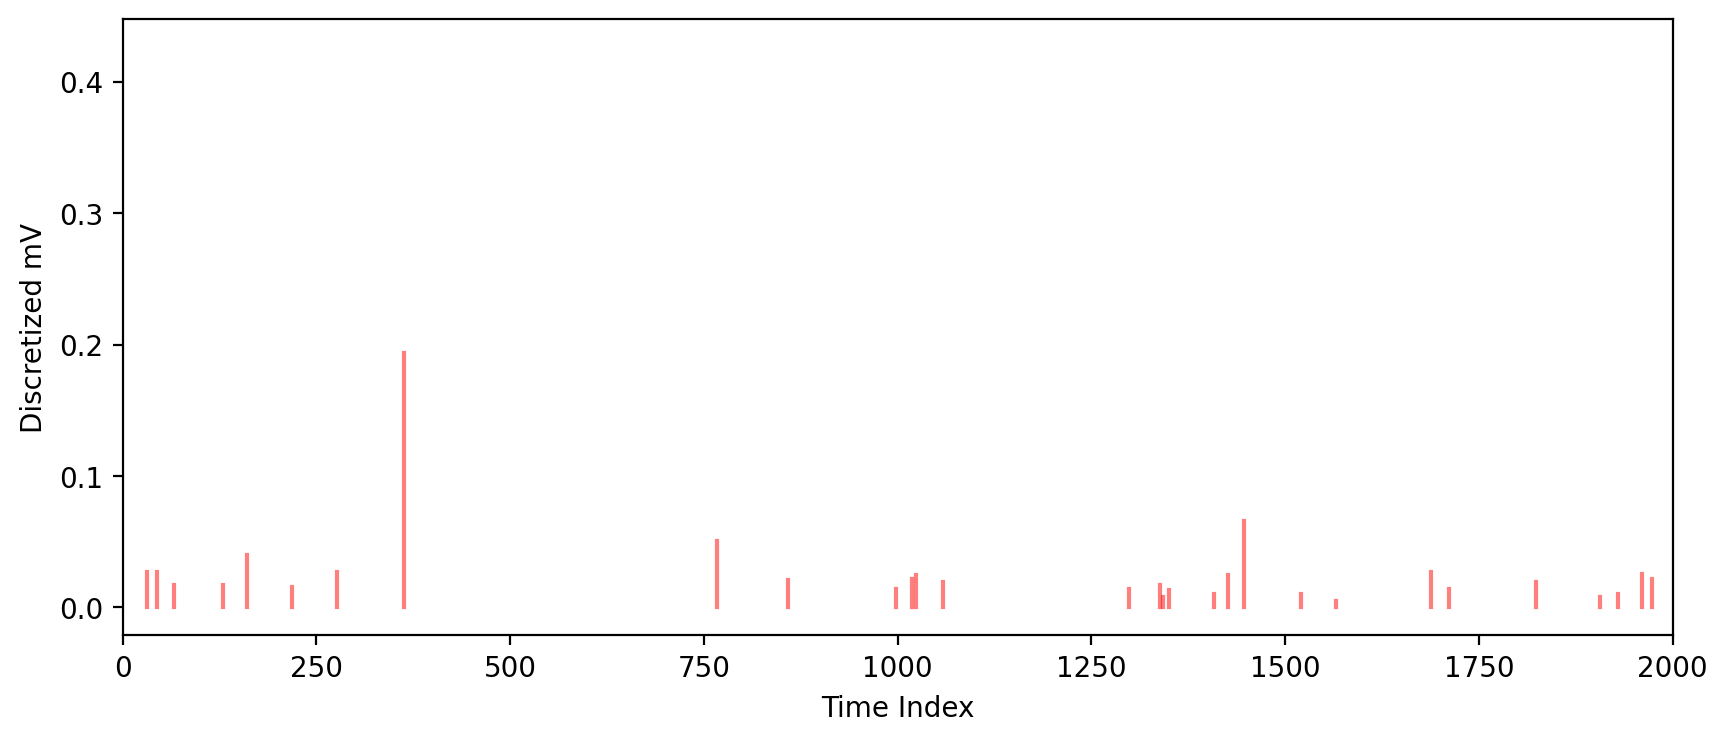

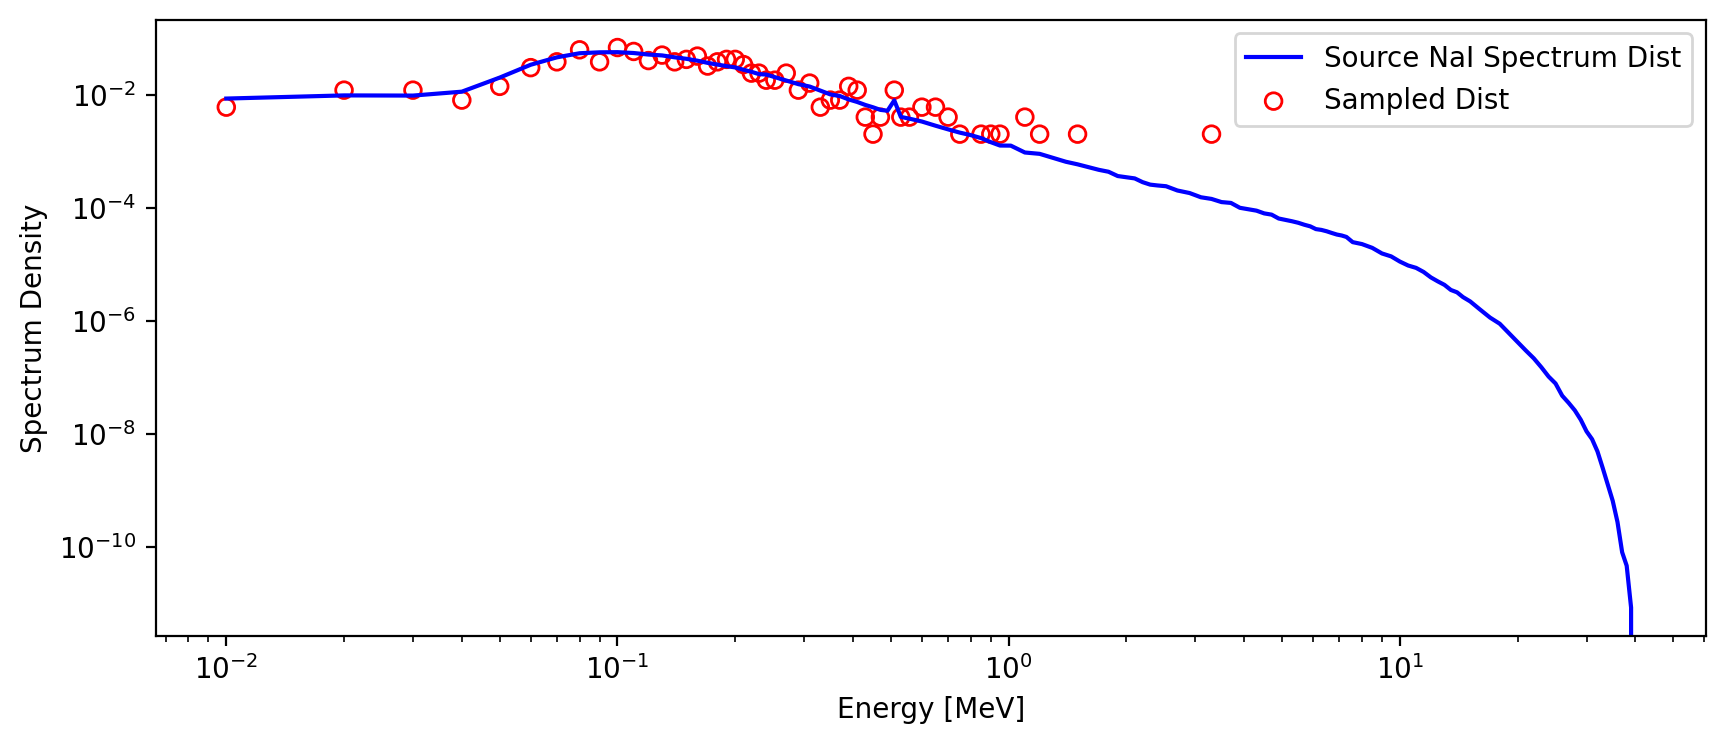

In [11]:
from util.DataGen import *
from util.Plotting import *

import numpy as np
import matplotlib.pyplot as plt

# Trace
sensor_type = 'NaI'
seed = 3
countrate = .5e6
total_time = 1e-3
noise_stdev = 0  # mV
bits = 24  # 8 bits is

print('{} Photons'.format(countrate * total_time))

dt = np.float64(25e-9)  # sampling rate in seconds. 40MHz

_, decimal_kernel = nai_pulse(1, 101, 1)
keV_per_area = .147  # determined by trial and error to match energy range of instrument
mV_per_ADC = 1000. / 4096.
area_per_peak = np.sum(decimal_kernel) / np.max(decimal_kernel)
mV_per_keV = mV_per_ADC / (keV_per_area * area_per_peak)
print('mV_per_keV', mV_per_keV)

#########################################################################################################################
# Spectrum trace

hera_trace, time_vector, volts_list, volts_time_index = spectrum_trace(
	count_rate_=countrate, dt_=dt, total_time_=total_time,
	pulse_=decimal_kernel, bin_energies_=binCenters, spectrum_=nai_spectrum_response,
	mV_per_keV_=mV_per_keV, noise_std_=noise_stdev, baseline_=0,
	sampling_ratio_=1, discretize=True, bits_=bits,
	seed_=seed, clip=False, debug=False)

print(
	hera_trace.shape,
	time_vector.shape,
	volts_list.shape,
	volts_time_index.shape,
)

energies = volts_list / mV_per_keV

##########################################################################################################################
N = hera_trace.size
trace_fft_noise = hera_trace

fig, axes = plt.subplots(1, 1, figsize=(10,4), dpi=200)
plot_photons(axes, volts_time_index, volts_list, label_='{} Photons'.format(len(volts_list)), color='r', alpha=.5)
xlim = [0, 2000]
axes.set_xlim(xlim)
axes.set_ylabel('Discretized mV')
axes.set_xlabel('Time Index')
# plt.show()
plt.savefig('figures/sample_photons.png')

fig, axes = plt.subplots(1, 1, figsize=(10,4), dpi=200)
axes.plot(binCenters, nai_spectrum_response/np.sum(nai_spectrum_response), 'b-', label='Source NaI Spectrum Dist')
hist, hist_bins = np.histogram(energies, bins=bins)
print(hist_bins.size, hist.size)
axes.scatter(binCenters, hist/np.sum(hist), marker='o', facecolors='None', color='r', label='Sampled Dist')
axes.set_yscale('log')
axes.set_xscale('log')
axes.set_xlabel('Energy [MeV]')
axes.set_ylabel('Spectrum Density')
axes.legend()
plt.savefig('figures/sample_spectrum.png')


Sample Size: 850


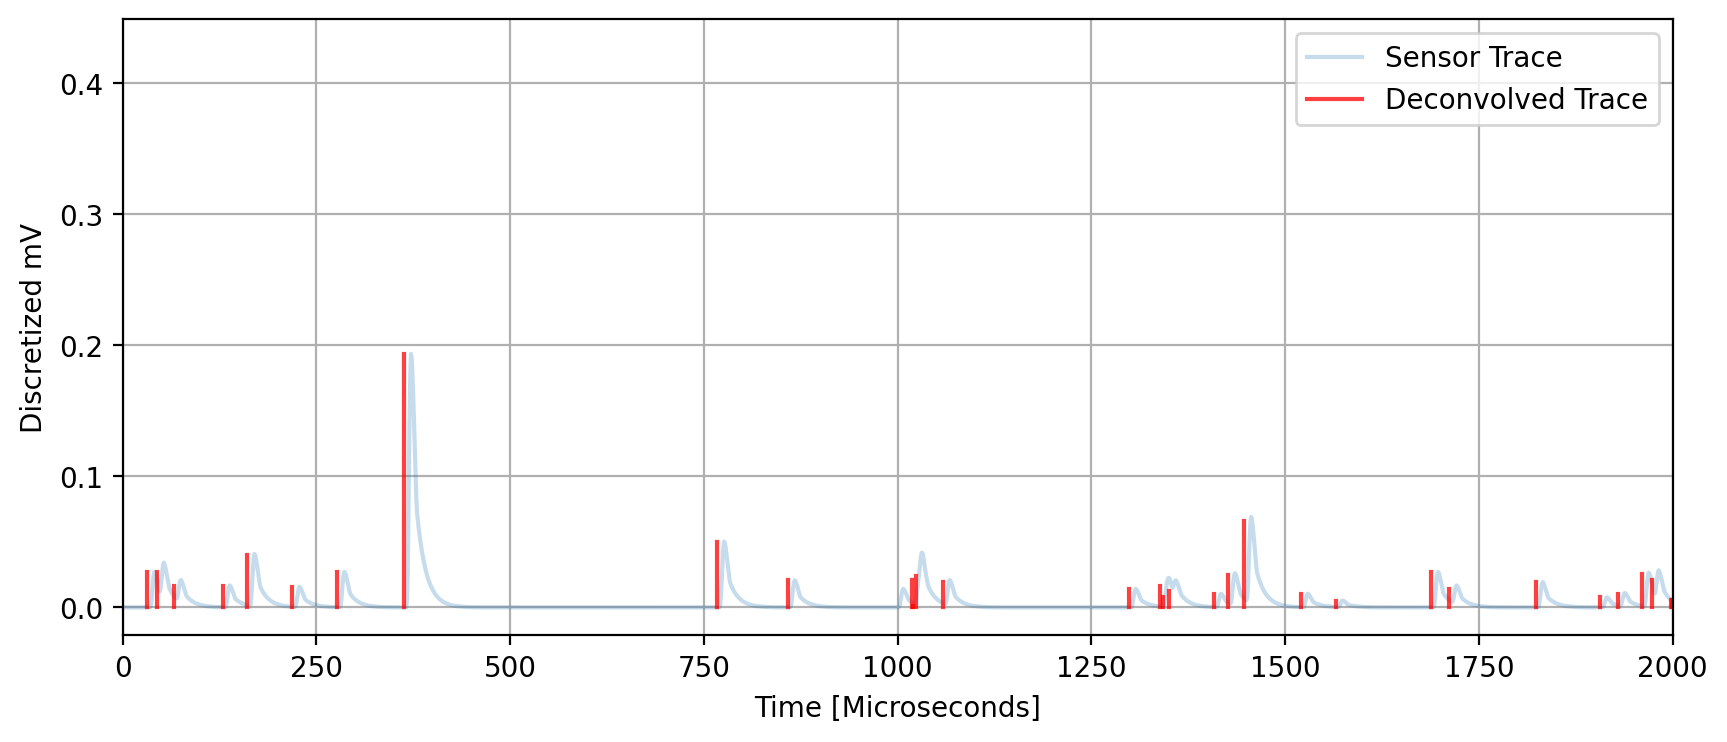

In [12]:
# Deconvolve 
fig, axes = plt.subplots(1, 1, figsize=(10,4), dpi=200)
axes.plot(hera_trace, label='Sensor Trace', alpha=.25)

threshold = 0
nnlsr_size = 1000
# nnlsr_deconv = td_nnlsr_deconvolve(trace, decimal_kernel)

if hera_trace.size <= nnlsr_size:
    blocks = 1
else:
    blocks = hera_trace.size // nnlsr_size
    if blocks * nnlsr_size != hera_trace.size:
        blocks += 1
nnlsr_deconv = []
for i in range(blocks):
    data = hera_trace[i * nnlsr_size:(i + 1) * nnlsr_size]
    nnlsr_deconv.append(td_nnlsr_deconvolve(data, decimal_kernel))
nnlsr_deconv = np.concatenate(nnlsr_deconv, axis=0)

thresholded_volts_list, thresholded_indeces = threshold_listmode(nnlsr_deconv, threshold)
plot_photons(structure=fig, magnitude=thresholded_volts_list, photons_=thresholded_indeces,
             label_='Deconvolved Trace', color='r', alpha=.75)

print('Sample Size: {}'.format(len(thresholded_volts_list)))

axes.set_xlim(xlim)
axes.legend(loc=1)
axes.set_ylabel('Discretized mV')
axes.set_xlabel('Time [Microseconds]')
axes.grid()
axes.legend()
plt.savefig('figures/trace_and_deconvolved.png')

In [13]:
deconvolved_energies = thresholded_volts_list / mV_per_keV
print('NNLSR Deconv detected {}/{} Photons'.format(deconvolved_energies.size, len(energies)))

NNLSR Deconv detected 850/500 Photons


In [14]:
###################################################################################
# TODO READ: = replacing zero with 1E-8 to avoid divide by zero in pymc.Interpolate
# TODO make it so Interpolate.dist() do not have same input size, ignore NaNs
val = 1E-16
nai_distribution[np.isnan(nai_distribution)] = val
nai_distribution[nai_distribution==0] = val

###################################################################################

# nai_distribution = np.log10(nai_distribution)
# print(energies)
# energies = np.log10(energies)
# print(energies)

In [15]:
t0 = time.time()
with pm.Model() as model:
    P_M_given_T = []
    for i in range(nai_distribution.shape[0]):
        P_M_given_Ti = pm.Interpolated.dist(x_points=binCenters, pdf_points=nai_distribution[i,:])
        P_M_given_T.append(P_M_given_Ti)
    
    w = pm.Dirichlet('weights', a=np.ones_like(binCenters))
    like = pm.Mixture('like', w=w, comp_dists=P_M_given_T, observed=energies)
    dmm_trace = pm.sample(draws=int(.5E3), tune=500, init="advi", chains=8, target_accept=.8, random_seed=0)
    # TODO compare categorical to mixture models
    
# 50 counts and 1K draws took 5 minutes
# 800 counts and 10K draws took 87 minutes
# 1K counts and 1K draws took 26 minutes
# 10K counts and 1K draws took 5.2 hours

# 1K counts, 500 draws, 8 chains took 20 minutes
# 1K counts, 10K draws, 8 chains took 2.4 hours
    
t1 = time.time()
total = t1 - t0
if total > 3600:
    print('Total Time: {:.2f} Hours'.format(total/3600))
elif total > 60:
    print('Total Time: {:.1f} Minutes'.format(total/60))

# with pm.Model() as model:
#     interp_pdf = pm.Interpolated.dist(x_points=x, pdf_points=y, testval=2.5)
#     w = pm.Dirichlet('w', a=np.array([1., 1.]))
#     like = pm.Mixture('like', w=w, comp_dists=[gaus, interp_pdf], testval=2.5)
#     


NameError: name 'pm' is not defined

In [ ]:
local = dmm_trace.posterior['weights'].data
n = 13
for i in range(local.shape[2]//n):
    start = i * n
    stop = n*(i+1)
    if stop >= local.shape[2]:
        stop = local.shape[2] - 1
    az.plot_trace(local[:,:,start:stop], figsize=(10, 4))
    
    fig = plt.gcf()
    axes = fig.axes
    base = '{:.2f} - {:.2f} MeV Weights'.format(binCenters[start], binCenters[stop])
    axes[0].set_title(base + ' Density')
    axes[0].set_xlabel('Value')
    axes[0].set_xlabel('Density')
    # axes[0].set_yscale('log')
    # axes[0].set_xscale('log')
    # axes[0].set_xlim([1E-5, 1E-1])
    # axes[0].set_ylim([1E-4, 1E4])
    
    axes[1].set_title(base + ' Trace')
    axes[1].set_ylabel('Value')
    axes[1].set_xlabel('Draw')
    plt.savefig('figures/weight_posterior_{}_{}.png'.format(start, stop))

In [ ]:
# local = dmm_trace.posterior['weights'].data
# n = 13
# fig, axes = plt.subplots(10,2, figsize=(10,10), dpi=200)
# for i, axis in enumerate(axes):
#     start = i * n
#     stop = n*(i+1)
#     if stop >= local.shape[2]:
#         stop = local.shape[2] - 1
#     az.plot_dist(local[:,:,start:stop], figsize=(6, 1), ax=axes)

In [ ]:
# Reshape multiple chains together and check that its correct
working = dmm_trace.posterior['weights'].data
weight_spectrum = working.reshape((-1, working.shape[2]))
# test = np.concatenate((working[0, :,:],working[1, :,:],working[2, :,:],working[3, :,:]), axis=0) #4 chains...
# print(test.shape)
# assert np.sum(weight_spectrum - test) == 0

# Sort values for Equitailed CI calcs later
sorted_weight_spectrum = np.sort(weight_spectrum, axis=0)
print(sorted_weight_spectrum.shape)



In [ ]:
#TODO what if we use different bins?

# TODO subtle but we have non constant bin widths, do we need to normalize taking into account binWidths?
# No? weights do not have bin widths coming out of mixture model? Or should the bin widths have been accounted for in the DMM directly?

# TODO all normalization should be done via integration method because we need to account for bin width, even for smaples...
# TODO everything is garbage, need to be comparing Estimated spectrum to DWYER...

weight_means = np.mean(sorted_weight_spectrum, axis=0)
weight_means /= np.sum(weight_means)
print(weight_means.size)

hist, _ = np.histogram(energies, bins=bins)

ci_95 = np.percentile(sorted_weight_spectrum, [2.5, 97.5], axis=0)
ci_90 = np.percentile(sorted_weight_spectrum, [5, 95], axis=0)
ci_80 = np.percentile(sorted_weight_spectrum, [10, 90], axis=0)
# ci_95 /= np.sum(ci_95*binWidths)
# ci_90 /= np.sum(ci_90*binWidths)
# ci_80 /= np.sum(ci_80*binWidths)

plt.figure(figsize=(7, 4), dpi=200)
plt.plot(binCenters, TGF_Spectrum/np.sum(TGF_Spectrum), 'b*', label='TGF Spectrum', alpha=.25, zorder=0)
plt.plot(binCenters, NaIResponse/np.sum(NaIResponse), 'orange', label='NaI Response', alpha=.25, zorder=0)
plt.plot(binCenters, weight_means, 'g', label='Posterior Mean', alpha=1, zorder=3)
plt.plot(binCenters, ci_80[0,:], 'r',  label='80% Credible Interval', alpha=.5, zorder=0)
plt.plot(binCenters, ci_80[1,:], 'r',  alpha=.5, zorder=0)
plt.plot(binCenters, ci_90[0,:], 'r',  label='90% Credible Interval', alpha=.25, zorder=0)
plt.plot(binCenters, ci_90[1,:], 'r',  alpha=.25, zorder=0)
plt.plot(binCenters, ci_95[0,:], 'r', label='95% Credible Interval', alpha=.125, zorder=0)
plt.plot(binCenters, ci_95[1,:], 'r',  alpha=.125, zorder=0)

plt.legend()
plt.ylim([1E-5, 1E-0])
plt.xlabel('Energy [MeV]')
plt.ylabel('Spectrum Density')
plt.yscale('log')
plt.xscale('log')
plt.savefig('figures/mean_and_CIs.png')

plt.figure(figsize=(7, 4), dpi=200)
plt.scatter(binCenters, hist/np.sum(hist), marker='o', facecolors='None', color='r', label='Dist. of Measured Samples', alpha=1, zorder=1)
plt.plot(binCenters, TGF_Spectrum/np.sum(TGF_Spectrum), 'b*', label='TGF Spectrum', alpha=.25, zorder=0)
plt.plot(binCenters, NaIResponse/np.sum(NaIResponse), 'orange', label='NaI Response', alpha=.25, zorder=0)
plt.plot(binCenters, weight_means, 'g', label='Posterior Mean', alpha=1, zorder=3)

plt.legend()
plt.ylim([1E-5, 1E-1])
plt.xlabel('Energy [MeV]')
plt.ylabel('Spectrum Density')
plt.yscale('log')
plt.xscale('log')
plt.savefig('figures/mean_and_samples.png')

In [ ]:
weight_mean_normalized = np.mean(sorted_weight_spectrum, axis=0)
weight_mean_normalized /= np.sum(weight_mean_normalized*binWidths)
joint_TM = nai_distribution * weight_mean_normalized[:, None]
joint_TM = joint_TM / np.sum(joint_TM)

plt.figure()
# print(bins.shape, binWidths.shape, nai_distribution.shape)
plt.pcolormesh(bins, bins, (nai_distribution/binWidths).T,
               shading=shading,cmap=cmap_color, norm=LogNorm(vmin=1E-3, vmax=1E0))
cb = plt.colorbar()
cb.ax.tick_params(labelsize=16)
cb.set_label(label='Truncated Probability Density',size=18)
plt.xlim(.1,35)
plt.ylim(.1,35)
plt.xscale('log')
plt.yscale('log')
plt.title('NaI Response Matrix',fontsize=20)
plt.xlabel('True Energy [MeV]',fontsize=18)
plt.ylabel('Measured Energy Distribution [MeV]',fontsize=18)
plt.tick_params(labelsize=16)

plt.figure()
# print(bins.shape, binWidths.shape, nai_distribution.shape)
plt.pcolormesh(bins, bins, (joint_TM/binWidths).T,
               shading=shading,cmap=cmap_color, norm=LogNorm(vmin=1E-3, vmax=1E0))
cb = plt.colorbar()
cb.ax.tick_params(labelsize=16)
cb.set_label(label='Truncated Probability Density',size=18)
plt.xlim(.1,1)
plt.ylim(.1,1)
plt.xscale('log')
plt.yscale('log')
plt.title('Estimated Joint Distribution',fontsize=20)
plt.xlabel('True Energy Distribution [MeV]',fontsize=18)
plt.ylabel('Measured Energy Distribution [MeV]',fontsize=18)
plt.tick_params(labelsize=16)
plt.savefig('figures/JointFinal.png')

In [ ]:
# # Find nearest measured energy bin in deconvolved spectrum
# diff = np.abs(deconvolved_energies[:, None] - bins[None, :])
# measured_bin_index = np.argmin(diff, axis=1)
# 
# fix, axis = plt.subplots(1,1, figsize=(10,6), dpi=200)
# image =  joint_T_M[:, measured_bin_index].T
# plt.pcolormesh(np.arange(image.shape[0] + 1), bins, image.T, shading='flat', cmap='inferno', norm=LogNorm())
# plt.title('Photon Energy Probabilities',fontsize=20)
# plt.ylabel('True Energy (MeV)',fontsize=18)
# plt.yscale('log')
# plt.tick_params(labelsize=16)
# cb = plt.colorbar()
# cb.ax.tick_params(labelsize=16)
# cb.set_label(label='Truncated Probability Density',size=18)

In [ ]:
# def log_likelihood_ratio(dist1_, dist2_, sample_, bins_):
#     index = np.argmin(np.abs(sample_[None, :] - bins[:, None]), axis=0)
#     print(index.shape)
#     sample_converted = bins_[index]
#     
#     dist1_ = dist1_ / (dist1_ * bins_)
#     sum_l_like = 0
#     for obs in sample_:
#         sum_l_like += np.log10()
    
    
    
    # sum the log likelihood to avoid underflow...
    
    # Just interpolate in logspace
    
    # find nearest bin in log space
    # diff = np.abs(sample_dist[:, None] - bins_dist[None, :])
    # measured_bin_index = np.argmin(diff, axis=1)
    # sampled_bins = 
    
    
    

In [ ]:
#TODO everything is garbage, need to be comparing Estimated spectrum to DWYER...